# Run DESeq2 with Dummy Interaction Term

In [2]:
# Load libraries
library("anndata")
library("DESeq2")
library("reticulate")

Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.3.2”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

   

In [3]:
# Use the path to your Python executable in the virtual environment
use_python("/lila/home/forsythb/.virtualenvs/r-reticulate/bin/")

# Look at where Python is located
py_config()

# Import scanpy
sc <- import("scanpy")

python:         /lila/home/forsythb/.virtualenvs/r-reticulate/bin/python
libpython:      /home/forsythb/anaconda3/lib/libpython3.8.so
pythonhome:     /lila/home/forsythb/.virtualenvs/r-reticulate:/lila/home/forsythb/.virtualenvs/r-reticulate
version:        3.8.18 (default, Sep 11 2023, 13:40:15)  [GCC 11.2.0]
numpy:          /lila/home/forsythb/.virtualenvs/r-reticulate/lib/python3.8/site-packages/numpy
numpy_version:  1.24.4

NOTE: Python version was forced by use_python() function

In [5]:
# Read in the adata
adata <- sc$read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.post.combined.h5ad")

In [6]:
# Extract count matrix from the raw layer
count_matrix <- adata$raw$X
count_matrix <- t(count_matrix)
count_matrix <- round(count_matrix)

In [7]:
# Define the column data
coldata <- adata$obs[,c("Tumor_Site","Culture_Media", "ZFP_Expression", "Batch", "Patient")]

# Convert column data to factors
coldata$Tumor_Site <- factor(coldata$Tumor_Site)
coldata$Culture_Media <- factor(coldata$Culture_Media)
coldata$ZFP_Expression <- factor(coldata$ZFP_Expression)
coldata$Batch <- factor(coldata$Batch)
coldata$Patient <- factor(coldata$Patient)

In [8]:
# Design a DESeqDataSet
dds_1 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ Tumor_Site + Culture_Media + Patient + ZFP_Expression:Culture_Media - 1
)

converting counts to integer mode



In [ ]:
# Add a pseudo-count of 1 to all counts
count_matrix <- counts(dds_1) + 1

# Specify the row names as the gene names
rownames(count_matrix) <- adata$raw$var_names

# Set the reference levels
coldata$Tumor_Site<-relevel(coldata$Tumor_Site,ref="Primary")
coldata$Culture_Media<-relevel(coldata$Culture_Media,ref="BASE")
coldata$ZFP_Expression<-relevel(coldata$ZFP_Expression,ref="CTRL")
coldata$Patient<-relevel(coldata$Patient,ref="125")
Tumor_Site:Culture_Media, ref = "base"

In [ ]:
# Design a DESeqDataSet with modified count matrix
dds_1 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ Tumor_Site + Culture_Media + Patient + ZFP_Expression:Culture_Media  
)

In [ ]:
# Perform DESeq analysis
dds_1 <- DESeq(dds_1)

In [1]:
# Load libraries
library("anndata")
library("DESeq2")
library("reticulate")

# Use the path to your Python executable in the virtual environment
use_python("/lila/home/forsythb/.virtualenvs/r-reticulate/bin/")

# Look at where Python is located
py_config()

# Import scanpy
sc <- import("scanpy")

# Read in the adata
adata <- sc$read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.post.combined.h5ad")

# Extract count matrix from the raw layer
count_matrix <- adata$raw$X
count_matrix <- t(count_matrix)
count_matrix <- round(count_matrix)

# Define the column data
coldata <- adata$obs[,c("Tumor_Site","Culture_Media", "ZFP_Expression", "Batch", "Patient")]

# Convert column data to factors
coldata$Tumor_Site <- factor(coldata$Tumor_Site)
coldata$Culture_Media <- factor(coldata$Culture_Media)
coldata$ZFP_Expression <- factor(coldata$ZFP_Expression)
coldata$Batch <- factor(coldata$Batch)
coldata$Patient <- factor(coldata$Patient)

# Design a DESeqDataSet
dds_1 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ Tumor_Site + Culture_Media + Patient + ZFP_Expression:Culture_Media 
)

# Add a pseudo-count of 1 to all counts
count_matrix <- counts(dds_1) + 1

# Specify the row names as the gene names
rownames(count_matrix) <- adata$raw$var_names

# Set the reference levels
coldata$Tumor_Site<-relevel(coldata$Tumor_Site,ref="Primary")
coldata$Culture_Media<-relevel(coldata$Culture_Media,ref="BASE")
coldata$ZFP_Expression<-relevel(coldata$ZFP_Expression,ref="CTRL")
coldata$Patient<-relevel(coldata$Patient,ref="125")

# Design a DESeqDataSet with modified count matrix
dds_1 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ Tumor_Site + Culture_Media + Patient + ZFP_Expression:Culture_Media  
)

# Perform DESeq analysis
dds_1 <- DESeq(dds_1)

# Extract results
result_names_1 <- resultsNames(dds_1)
result_names_1

# Specify the contrast and extract results
res_1 <- results(dds_1)
res_1

# Specify the file path where you want to save the results
result_file <- "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacells_zfpexp_intcm_results.csv"

# Write the results table to a CSV file
write.csv(as.data.frame(res_1), file = result_file)

# Save the DESeqDataSet object
saveRDS(dds_1, file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacells_zfpexp_intcm_dds.rds")

# Save the DESeq results
saveRDS(results(dds_1), file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacells_zfpexp_intcm_results.rds")

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loa

python:         /lila/home/forsythb/.virtualenvs/r-reticulate/bin/python
libpython:      /home/forsythb/anaconda3/lib/libpython3.8.so
pythonhome:     /lila/home/forsythb/.virtualenvs/r-reticulate:/lila/home/forsythb/.virtualenvs/r-reticulate
version:        3.8.18 (default, Sep 11 2023, 13:40:15)  [GCC 11.2.0]
numpy:          /lila/home/forsythb/.virtualenvs/r-reticulate/lib/python3.8/site-packages/numpy
numpy_version:  1.24.4

NOTE: Python version was forced by use_python() function

converting counts to integer mode

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



[1] "Intercept"                                        
[2] "Tumor_Site_Metastatic_vs_Primary"                 
[3] "Culture_Media_Dedifferentiated_vs_BASE"           
[4] "Culture_Media_HISC_vs_BASE"                       
[5] "Patient_146_vs_125"                               
[6] "Culture_MediaBASE.ZFP_ExpressionZFPKD"            
[7] "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD"
[8] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

log2 fold change (MLE): Culture MediaHISC.ZFP ExpressionZFPKD 
Wald test p-value: Culture MediaHISC.ZFP ExpressionZFPKD 
DataFrame with 32485 rows and 6 columns
          baseMean log2FoldChange     lfcSE      stat      pvalue       padj
         <numeric>      <numeric> <numeric> <numeric>   <numeric>  <numeric>
A1BG       1.02231    -0.00624474 0.0695281 -0.089816    0.928433         NA
A1BG-AS1   1.01236     0.00743605 0.0700204  0.106198    0.915425         NA
A1CF       3.33497     0.04018658 0.0441125  0.911002    0.362294   0.788559
A2M        1.02463    -0.03865781 0.0693741 -0.557237    0.577365         NA
A2M-AS1    1.02563    -0.02910631 0.0693426 -0.419746    0.674671         NA
...            ...            ...       ...       ...         ...        ...
ZXDC       3.80565    -0.02883310 0.0353559 -0.815511 4.14780e-01 0.82073429
ZYG11A     1.04943    -0.03117807 0.0686807 -0.453957 6.49860e-01         NA
ZYG11B     3.71665    -0.03097624 0.0369126 -0.839178 4.01370e-01 0.8

In [1]:
# If not already downloaded in environment, then download DESeq2
if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}
BiocManager::install("DESeq2")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.18 (BiocManager 1.30.22), R 4.3.1 (2023-06-16)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'DESeq2'”
Old packages: 'BiocVersion', 'bslib', 'Cairo', 'cli', 'cluster', 'cpp11',
  'crosstalk', 'curl', 'data.table', 'dplyr', 'dqrng', 'DT', 'edgeR',
  'evaluate', 'fansi', 'filelock', 'foreign', 'htmltools', 'htmlwidgets',
  'httpuv', 'igraph', 'jsonlite', 'later', 'lifecycle', 'Matrix', 'nlme',
  'progress', 'ragg', 'rlang', 'rpart', 'RSQLite', 'Rtsne', 'S4Vectors',
  'sass', 'scales', 'scater', 'shiny', 'stringi', 'tinytex', 'vctrs', 'XML',
  'xml2'



In [ ]:
install.packages("reticulate")

In [1]:
# Load libraries
library(DESeq2)
library(anndata)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loa

In [2]:
# # Read h5ad file
# adata <- read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.post.combined.h5ad")
# adata

# Subset the data to contain only samples from Patient 125
# Read h5ad file
adata <- read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.filteredmultiplex.combined.hvg_5000.h5ad")

Error in python_config_impl(python) : 
  Error running '/lila/home/forsythb/.local/share/r-miniconda/envs/r-reticulate/bin/python': No such file.


In [5]:
# Extract count matrix
count_matrix <- adata$raw$X
count_matrix <- t(count_matrix) # The number of columns in the count matrix have to match the number of rows in the coldata
count_matrix <- round(count_matrix) # Values in the count matrix have to be integer values
count_matrix

# Extract count matrix from the raw layer
# Extract count matrix from the raw layer
# Subset adata to only contain samples from patient 125
# patient_125_indices <- adata$obs$Patient == '125'
# adata_patient_125 <- adata[patient_125_indices, ]

# # Extract the count matrix from the raw data
# count_matrix <- adata_patient_125$raw$X
# count_matrix <- t(count_matrix)
# count_matrix <- round(count_matrix)

0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,3,2,0,0,1,2,0,0,1,⋯,3,0,0,0,0,0,0,1,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [6]:
# Define the column data
coldata <- adata$obs[,c("Tumor_Site","Culture_Media", "ZFP_Expression", "Batch", "Patient")]

# Convert column data to factors
coldata$Tumor_Site <- factor(coldata$Tumor_Site)
coldata$Culture_Media <- factor(coldata$Culture_Media)
coldata$ZFP_Expression <- factor(coldata$ZFP_Expression)
coldata$Batch <- factor(coldata$Batch)
coldata$Patient <- factor(coldata$Patient)

In [ ]:
coldata

In [23]:
table(coldata$Culture_Media)
table(coldata$ZFP_Expression)


            BASE Dedifferentiated             HISC 
            5771               26            12282 


  CTRL ZFP_KD 
  6507  11572 

In [7]:
# Design a DESeqDataSet
dds_1 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  # The formula should be Tumor_Site + Culture_Media + ZFP_Expression, but Patient 125 only has Primary tumor sites
  design = ~ Tumor_Site + Culture_Media + ZFP_Expression + ZFP_Expression:Culture_Media
)


converting counts to integer mode



In [8]:
# Subset the data to contain only samples from Patient 125
# Read h5ad file
adata <- read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.post.combined.h5ad")

# Subset adata to only contain samples from patient 125
patient_125_indices <- adata$obs$Patient == '125'
adata_patient_125 <- adata[patient_125_indices, ]

# Verify that adata_patient_125 only contains samples from patient 125
print(unique(adata_patient_125$obs$Patient))

[1] 125
Levels: 125


In [93]:
length(adata_patient_125$raw$var_names)

[1] 32491

In [94]:
count_matrix <- adata_patient_125$raw$X
count_matrix <- t(count_matrix)
count_matrix <- round(count_matrix)

In [54]:
length(adata_patient_125$var_names)

[1] 4837

In [98]:
# Define the column data
coldata <- adata_patient_125$obs[,c("Tumor_Type","Culture_Media", "ZFP_Expression", "Batch", "Patient")]

In [97]:
# Convert column data to factors
coldata$Tumor_Site <- factor(coldata$Tumor_Type)
coldata$Culture_Media <- factor(coldata$Culture_Media)
coldata$ZFP_Expression <- factor(coldata$ZFP_Expression)
coldata$Batch <- factor(coldata$Batch)
coldata$Patient <- factor(coldata$Patient)

In [12]:
# Design a DESeqDataSet
dds_1 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  # The formula should be Tumor_Site + Culture_Media + ZFP_Expression, but Patient 125 only has Primary tumor sites
  design = ~ Tumor_Site + Culture_Media + ZFP_Expression + ZFP_Expression:Culture_Media
)

converting counts to integer mode



In [8]:
# Add a pseudo-count of 1 to all counts
count_matrix <- counts(dds_1) + 1

In [9]:
# Add gene names to the count matrix
rownames(count_matrix) <- adata$raw$var_names

In [10]:
# Set the reference levels
dds_1$Tumor_Site<-relevel(dds_1$Tumor_Site,ref="Primary")
dds_1$Culture_Media<-relevel(dds_1$Culture_Media,ref="BASE")
dds_1$ZFP_Expression<-relevel(dds_1$ZFP_Expression,ref="CTRL")
dds_1$Patient<-relevel(dds_1$Patient,ref="125")

In [ ]:
# Perform DESeq analysis
dds_1 <- DESeq(dds_1)

estimating size factors

estimating dispersions

gene-wise dispersion estimates



In [ ]:
# Extract results
result_names_1 <- resultsNames(dds_1)
result_names_1

# Specify the contrast and extract results
res_1 <- results(dds_1)
res_1

In [62]:
# Check the dimensions of adata$raw$X
dim(adata$raw$X)

# Check the length of common_genes
length(common_genes)

[1]  3934 32491

[1] 4837

In [65]:
print(adata$raw$X)

3934 x 32491 sparse Matrix of class "dgRMatrix"
                                                                                        
   [1,] . .  . . . . . . . . .  1  5 . .  1 . .  .  3   3  3  8 .  3 .  5  1  2  .  3  .
   [2,] . . 15 . . . . . . . .  .  5 . .  . . .  1  4   3  3  4 .  . .  4  1  2  1  4  .
   [3,] . .  . . . . . . . . .  9 19 . .  9 . .  1 30  25 12 18 .  8 . 29  4 17 11 13  1
   [4,] . . 15 . . . . . . . .  3  4 . .  . . .  .  4   5  1  4 .  2 .  5  .  .  2  6  .
   [5,] . . 15 . . . . . . . .  8 13 1 .  . . .  2  6   5  7 24 .  7 .  6  2 11  7 15  .
   [6,] . .  1 . . . . . . 3 .  5 10 . .  . . .  3  9  22 11 24 1  3 .  7  1  8 10 14 10
   [7,] . .  5 . . . . . . . .  1  1 . .  . . .  .  8   3  5  9 .  2 .  8  2  3  2  9  .
   [8,] . .  1 . . . . . . . . 11 13 . .  1 . .  1 13   5 10 15 .  2 .  5  . 15  6 10  .
   [9,] . . 40 . . . . . . . . 10 23 . .  1 . .  3 13  15 15 20 .  1 . 19  6 13  7 17  .
  [10,] . .  2 . . . . . . . .  1  3 . .  . . .  1  5   8  2  

In [70]:
# Find indices of var_names in adata$raw$var_names that match with adata_patient_125$var_names
matching_indices <- match(adata_patient_125$var_names, adata$raw$var_names)
length(matching_indices)

# Filter out NA values (unmatched var_names) from matching_indices
matching_indices <- matching_indices[!is.na(matching_indices)]
length(matching_indices)

# Now, matching_indices contains the indices in adata$raw$var_names corresponding to adata_patient_125$var_names
print(matching_indices)

[1] 4837

[1] 4837

   [1]    16    22    23    26    31    37    41    44    51    71    76    77
  [13]    78    87    89    91    92    97   110   117   120   123   137   138
  [25]   151   153   175   219   223   240   251   262   351   355   374   390
  [37]   405   407   422   432   440   470   477   546   550   551   571   587
  [49]   655   717   728   816   818   822   839   886   901   903   905   906
  [61]   907   921   931   964   975   981   991   993  1021  1041  1146  1153
  [73]  1201  1204  1225  1241  1257  1258  1265  1280  1287  1289  1307  1316
  [85]  1326  1449  1480  1503  1504  1565  1573  1615  1629  1630  1640  1648
  [97]  1649  1668  1669  1682  1701  1717  1718  1754  1839  1887  1908  1931
 [109]  1941  1954  1955  1967  2053  2054  2071  2082  2097  2100  2131  2194
 [121]  2218  2221  2264  2276  2312  2344  2365  2370  2378  2381  2401  2409
 [133]  2460  2461  2503  2512  2524  2529  2564  2632  2649  2657  2658  2676
 [145]  2687  2696  2701  2791  2811  2827  2837  28

In [77]:
# Convert the sparse matrix to a dense matrix
dense_matrix <- as.matrix(adata$raw$X)

# Keep only the columns based on matching_indices
filtered_matrix <- dense_matrix[, matching_indices]

# Convert the filtered matrix back to a sparse matrix (if needed)
#filtered_sparse_matrix <- Matrix::Matrix(filtered_matrix, sparse = TRUE)

# Update adata$raw$X with the filtered matrix
#adata$raw$X <- filtered_matrix

In [82]:
count_matrix <- filtered_matrix
count_matrix <- t(count_matrix)
count_matrix <- round(count_matrix)
count_matrix

1,0,9,0,0,0,0,1,1,0,⋯,0,0,1,0,0,0,0,0,2,0
3,3,12,1,7,11,5,10,15,2,⋯,3,7,12,6,3,2,0,0,8,12
8,4,18,4,24,24,9,15,20,0,⋯,10,8,9,8,2,0,0,1,10,14
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,4,13,6,15,14,9,10,17,0,⋯,5,17,11,6,0,0,0,5,15,10
0,3,7,3,2,22,1,0,3,4,⋯,4,3,4,6,4,3,2,1,2,0
0,0,0,1,0,1,0,0,1,0,⋯,0,0,0,0,1,0,0,0,0,0
0,0,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,5,0,0,0,0
21,29,84,5,53,143,14,31,43,16,⋯,8,30,61,12,29,3,6,2,27,26
0,1,0,0,0,9,0,1,3,0,⋯,0,0,3,2,0,0,1,0,1,0
13,0,50,6,56,34,9,28,31,0,⋯,5,18,18,6,1,3,0,0,21,24


In [61]:
# Get the common genes
common_genes <- intersect(adata_patient_125$var_names, adata$raw$var_names)
length(common_genes)

# Filter the raw count matrix to include only common genes
filtered_raw_matrix <- adata$raw$X[, common_genes]

# Update the count matrix in the raw layer
#adata$raw$X <- filtered_raw_matrix

[1] 4837

ERROR: Error in .subscript.2ary(x, , j, drop = TRUE): subscript out of bounds


In [51]:
# Extract count matrix from the raw layer
count_matrix <- adata$raw$var_names
count_matrix

[1] "A1BG"              "A1BG-AS1"          "A1CF"             
    [4] "A2M"               "A2M-AS1"           "A2ML1"            
    [7] "A2ML1-AS1"         "A2ML1-AS2"         "A3GALT2"          
   [10] "A4GALT"            "A4GNT"             "AAAS"             
   [13] "AACS"              "AADAC"             "AADACL2"          
   [16] "AADACL2-AS1"       "AADACL3"           "AADACL4"          
   [19] "AADAT"             "AAGAB"             "AAK1"             
   [22] "AAMDC"             "AAMP"              "AANAT"            
   [25] "AAR2"              "AARD"              "AARS"             
   [28] "AARS2"             "AARSD1"            "AASDH"            
   [31] "AASDHPPT"          "AASS"              "AATBC"            
   [34] "AATF"              "AATK"              "ABALON"           
   [37] "ABAT"              "ABCA1"             "ABCA10"           
   [40] "ABCA12"            "ABCA13"            "ABCA2"            
   [43] "ABCA3"             "ABCA4"             "ABCA5"            
   [46] "ABCA6"             "ABCA7"             "ABCA8"            
   [49] "ABCA9"             "ABCA9-AS1"         "ABCB1"            
   [52] "ABCB10"            "ABCB11"            "ABCB4"            
   [55] "ABCB5"             "ABCB6"             "ABCB7"            
   [58] "ABCB8"             "ABCB9"             "ABCC1"            
   [61] "ABCC10"            "ABCC11"            "ABCC12"           
   [64] "ABCC2"             "ABCC3"             "ABCC4"            
   [67] "ABCC5"             "ABCC5-AS1"         "ABCC6"            
   [70] "ABCC8"             "ABCC9"             "ABCD1"            
   [73] "ABCD2"             "ABCD3"             "ABCD4"            
   [76] "ABCE1"             "ABCF1"             "ABCF2"            
   [79] "ABCF3"             "ABCG1"             "ABCG2"            
   [82] "ABCG4"             "ABCG5"             "ABCG8"            
   [85] "ABHD1"             "ABHD10"            "ABHD11"           
   [88] "ABHD12"            "ABHD12B"           "ABHD13"           
   [91] "ABHD14A"           "ABHD14B"           "ABHD15"           
   [94] "ABHD15-AS1"        "ABHD16A"           "ABHD16B"          
   [97] "ABHD17A"           "ABHD17B"           "ABHD17C"          
  [100] "ABHD18"            "ABHD2"             "ABHD3"            
  [103] "ABHD4"             "ABHD5"             "ABHD6"            
  [106] "ABHD8"             "ABI1"              "ABI2"             
  [109] "ABI3"              "ABI3BP"            "ABITRAM"          
  [112] "ABL1"              "ABL2"              "ABLIM1"           
  [115] "ABLIM2"            "ABLIM3"            "ABO"              
  [118] "ABR"               "ABRA"              "ABRACL"           
  [121] "ABRAXAS1"          "ABRAXAS2"          "ABT1"             
  [124] "ABTB1"             "ABTB2"             "AC000032.1"       
  [127] "AC000058.1"        "AC000061.1"        "AC000065.1"       
  [130] "AC000065.2"        "AC000068.1"        "AC000068.2"       
  [133] "AC000068.3"        "AC000072.1"        "AC000082.1"       
  [136] "AC000085.1"        "AC000099.1"        "AC000113.1"       
  [139] "AC000120.1"        "AC000123.1"        "AC000124.1"       
  [142] "AC000403.1"        "AC001226.1"        "AC002044.1"       
  [145] "AC002056.2"        "AC002057.2"        "AC002059.1"       
  [148] "AC002064.1"        "AC002064.2"        "AC002066.1"       
  [151] "AC002069.2"        "AC002070.1"        "AC002072.1"       
  [154] "AC002074.1"        "AC002074.2"        "AC002076.1"       
  [157] "AC002091.1"        "AC002094.2"        "AC002094.4"       
  [160] "AC002101.1"        "AC002115.1"        "AC002116.2"       
  [163] "AC002128.1"        "AC002128.2"        "AC002306.1"       
  [166] "AC002310.1"        "AC002310.2"        "AC002331.1"       
  [169] "AC002347.1"        "AC002347.2"        "AC002351.1"       
  [172] "AC002375.1"        "AC002377.1"        "AC002378.1"       
  [175] "AC002383.1"        "AC002386.1"        "AC002398.1"

In [37]:
adata_patient_125$raw

In [23]:
adata_patient_125

View of AnnData object with n_obs × n_vars = 1201 × 4837
    obs: 'Patient', 'Tumor_Type', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch', 'phenograph', 'leiden'
    uns: 'diffmap_evals', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    layers: 'raw', 'without_log'
    obsp: 'connectivities', 'distances'

In [24]:
# Define the column data
coldata <- adata_patient_125$obs[,c("Tumor_Type","Culture_Media", "ZFP_Expression", "Batch", "Patient")]
coldata

,Tumor_Type,Culture_Media,ZFP_Expression,Batch,Patient
,<fct>,<fct>,<fct>,<dbl>,<fct>
125_P_HISC_ZFPKD_1_SEACell-149,Primary,HISC,ZFPKD,1,125
125_P_HISC_ZFPKD_2_SEACell-219,Primary,HISC,ZFPKD,1,125
125_P_BASE_ZFPKD_2_SEACell-36,Primary,BASE,ZFPKD,0,125
125_P_HISC_CTRL_1_SEACell-12,Primary,HISC,CTRL,1,125
125_P_HISC_CTRL_1_SEACell-142,Primary,HISC,CTRL,1,125
125_P_BASE_ZFPKD_1_SEACell-149,Primary,BASE,ZFPKD,0,125
125_P_HISC_ZFPKD_2_SEACell-79,Primary,HISC,ZFPKD,1,125
125_P_HISC_CTRL_1_SEACell-18,Primary,HISC,CTRL,1,125
125_P_HISC_ZFPKD_1_SEACell-272,Primary,HISC,ZFPKD,1,125


In [83]:
# Convert column data to factors
coldata$Tumor_Site <- factor(coldata$Tumor_Type)
coldata$Culture_Media <- factor(coldata$Culture_Media)
coldata$ZFP_Expression <- factor(coldata$ZFP_Expression)
coldata$Batch <- factor(coldata$Batch)
coldata$Patient <- factor(coldata$Patient)
coldata

,Tumor_Type,Culture_Media,ZFP_Expression,Batch,Patient,Tumor_Site
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
125_P_HISC_ZFPKD_1_SEACell-149,Primary,HISC,ZFPKD,1,125,Primary
125_P_HISC_ZFPKD_2_SEACell-219,Primary,HISC,ZFPKD,1,125,Primary
125_P_BASE_ZFPKD_2_SEACell-36,Primary,BASE,ZFPKD,0,125,Primary
125_P_HISC_CTRL_1_SEACell-12,Primary,HISC,CTRL,1,125,Primary
125_P_HISC_CTRL_1_SEACell-142,Primary,HISC,CTRL,1,125,Primary
125_P_BASE_ZFPKD_1_SEACell-149,Primary,BASE,ZFPKD,0,125,Primary
125_P_HISC_ZFPKD_2_SEACell-79,Primary,HISC,ZFPKD,1,125,Primary
125_P_HISC_CTRL_1_SEACell-18,Primary,HISC,CTRL,1,125,Primary
125_P_HISC_ZFPKD_1_SEACell-272,Primary,HISC,ZFPKD,1,125,Primary


In [84]:
# Design a DESeqDataSet
dds_1 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  # The formula should be Tumor_Site + Culture_Media + ZFP_Expression, but Patient 125 only has Primary tumor sites
  design = ~ Culture_Media + ZFP_Expression 
)

ERROR: Error in DESeqDataSetFromMatrix(countData = count_matrix, colData = coldata, : ncol(countData) == nrow(colData) is not TRUE


In [85]:
# Add a pseudo-count of 1 to all counts
count_matrix <- counts(dds_1) + 1

In [29]:
count_matrix

125_P_HISC_ZFPKD_1_SEACell-149,125_P_HISC_ZFPKD_2_SEACell-219,125_P_BASE_ZFPKD_2_SEACell-36,125_P_HISC_CTRL_1_SEACell-12,125_P_HISC_CTRL_1_SEACell-142,125_P_BASE_ZFPKD_1_SEACell-149,125_P_HISC_ZFPKD_2_SEACell-79,125_P_HISC_CTRL_1_SEACell-18,125_P_HISC_ZFPKD_1_SEACell-272,125_P_HISC_ZFPKD_1_SEACell-115,⋯,125_P_HISC_CTRL_1_SEACell-9,125_P_BASE_CTRL_1_SEACell-94,125_P_HISC_ZFPKD_2_SEACell-234,125_P_BASE_CTRL_1_SEACell-133,125_P_HISC_ZFPKD_1_SEACell-6,125_P_HISC_CTRL_1_SEACell-246,125_P_HISC_ZFPKD_1_SEACell-28,125_P_BASE_ZFPKD_1_SEACell-58,125_P_BASE_ZFPKD_2_SEACell-14,125_P_HISC_CTRL_1_SEACell-249
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,2,2,1,1,1,1,1,1,⋯,1,1,1,3,2,1,1,5,1,2
1,1,1,1,1,1,1,1,1,1,⋯,2,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,3,2,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,4,1,1,1,1,1,1,1,⋯,1,1,1,3,1,1,1,1,1,1


In [28]:
# Add gene names to the count matrix
rownames(count_matrix) <- adata_patient_125$var_names

ERROR: Error in dimnames(x) <- dn: length of 'dimnames' [1] not equal to array extent


In [16]:
# Design a DESeqDataSet with modified count matrix
dds_1 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ Culture_Media + ZFP_Expression 
)

converting counts to integer mode



In [71]:
# Perform DESeq analysis
dds_1 <- DESeq(dds_1)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates



In [72]:
# Extract results
result_names_1 <- resultsNames(dds_1)
result_names_1

# Specify the contrast and extract results
res_1 <- results(dds_1)
res_1

[1] "Intercept"                             
[2] "Tumor_Site_Primary_vs_Metastatic"      
[3] "Culture_Media_Dedifferentiated_vs_BASE"
[4] "Culture_Media_HISC_vs_BASE"            
[5] "ZFP_Expression_ZFPKD_vs_CTRL"          
[6] "Patient_146_vs_125"

log2 fold change (MLE): Patient 146 vs 125 
Wald test p-value: Patient 146 vs 125 
DataFrame with 32435 rows and 6 columns
       baseMean log2FoldChange     lfcSE       stat       pvalue         padj
      <numeric>      <numeric> <numeric>  <numeric>    <numeric>    <numeric>
1       2.03550    -0.00373362 0.0408552 -0.0913867     0.927185     0.999867
2       2.02451     0.00612029 0.0409559  0.1494359     0.881210     0.999867
3      10.00799     1.87069649 0.0392843 47.6194044     0.000000     0.000000
4       2.03601     0.01759731 0.0408145  0.4311532     0.666357     0.895247
5       2.03703     0.01481611 0.0408134  0.3630208     0.716589     0.935831
...         ...            ...       ...        ...          ...          ...
32431  10.29810      -0.633868 0.0343817 -18.436220  6.72842e-76  5.64025e-75
32432   2.06465       0.024043 0.0405878   0.592369  5.53604e-01  7.84315e-01
32433   9.93330      -0.484756 0.0350079 -13.847050  1.32544e-43  7.21599e-43
32434   5.87379    

In [ ]:
# Specify the file path where you want to save the results
result_file <- "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/results_1.csv"

# Write the results table to a CSV file
write.csv(as.data.frame(res_1), file = result_file, row.names = FALSE)

# Save the DESeqDataSet object
saveRDS(dds_1, file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_dataset_1.rds")

# Save the DESeq results
saveRDS(results(dds_1), file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_results_1.rds")

In [ ]:
# Design a DESeqDataSet with offset
dds_2 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ Tumor_Type + Culture_Media + ZFP_Expression + Batch
)

In [ ]:
# Perform DESeq analysis
dds_2 <- DESeq(dds_2)

In [ ]:
# Extract results
result_names_2 <- resultsNames(dds_2)
result_names_2

# Specify the contrast and extract results
res_2 <- results(dds_2)
res_2

In [ ]:
# Specify the file path where you want to save the results
result_file <- "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/results_2.csv"

# Write the results table to a CSV file
write.csv(as.data.frame(res_2), file = result_file, row.names = FALSE)

# Save the DESeqDataSet object
saveRDS(dds_2, file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_dataset_2.rds")

# Save the DESeq results
saveRDS(results(dds_2), file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_results_2.rds")

In [ ]:
# Design a DESeqDataSet with offset
dds_3 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ Tumor_Type + Culture_Media + ZFP_Expression:Culture_Media
)

In [ ]:
# Perform DESeq analysis
dds_3 <- DESeq(dds_3)

In [ ]:
# Extract results
result_names_3 <- resultsNames(dds_3)
result_names_3

# Specify the contrast and extract results
res_3 <- results(dds_3)
res_3

In [ ]:
# Specify the file path where you want to save the results
result_file <- "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/results_3.csv"

# Write the results table to a CSV file
write.csv(as.data.frame(res_3), file = result_file, row.names = FALSE)

# Save the DESeqDataSet object
saveRDS(dds_3, file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_dataset_3.rds")

# Save the DESeq results
saveRDS(results(dds_3), file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_results_3.rds")

In [ ]:
# Design a DESeqDataSet with offset
dds_4 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ Tumor_Type + Culture_Media + ZFP_Expression:Tumor_Type
)

In [ ]:
# Perform DESeq analysis
dds_4 <- DESeq(dds_4)

In [ ]:
# Extract results
result_names_4 <- resultsNames(dds_4)
result_names_4

# Specify the contrast and extract results
res_4 <- results(dds_4)
res_4

In [ ]:
# Specify the file path where you want to save the results
result_file <- "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/results_4.csv"

# Write the results table to a CSV file
write.csv(as.data.frame(res_4), file = result_file, row.names = FALSE)

# Save the DESeqDataSet object
saveRDS(dds_4, file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_dataset_4.rds")

# Save the DESeq results
saveRDS(results(dds_4), file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_results_4.rds")

In [ ]:
# Create the offset_matrix
offset_values <- rep(1, nrow(count_matrix))
offset_matrix <- matrix(offset_values, nrow = nrow(count_matrix), ncol = ncol(count_matrix))
#offset_matrix

In [ ]:
coldata

In [60]:
# Design a DESeqDataSet with offset
dds_1 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ ZFP_Expression, 
  offset = log(offset_matrix) 
)

# Perform DESeq analysis
dds_1 <- DESeq(dds_1)

# Extract results
result_names <- resultsNames(dds_1)
res_1 <- results(dds_1)

In [ ]:
# Specify the file path where you want to save the results
result_file <- "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/results_1.csv"

# Write the results table to a CSV file
write.csv(as.data.frame(res_1), file = result_file, row.names = FALSE)

# Save the DESeqDataSet object
saveRDS(dds_1, file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_dataset_1.rds")

# Save the DESeq results
saveRDS(results(dds_1), file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_results_1.rds")

In [8]:
# Design a DESeqDataSet with offset
dds_2 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ ZFP_Expression, 
)

converting counts to integer mode



In [10]:
dds_2

class: DESeqDataSet 
dim: 5000 59140 
metadata(1): version
assays(1): counts
rownames(5000): A2ML1 AADACL2 ... ZSCAN32 ZWINT
rowData names(0):
colnames(59140): 146P_BASE_shZFP36L2_3_TTAGGGTCAGTAACGG-1
  KG146Li_BASE_shZFP36L2_4_CGTTAGACACGTAACT-1 ...
  146P_HISC_shZFP36L2_3_TCATCATAGATCGGTG-1
  125P_HISC_shZFP36L2_4_TCATCATCAGGTACGA-1
colData names(4): Tumor_Site Culture_Media ZFP_Expression Batch

In [9]:
# Perform DESeq analysis
dds_2 <- DESeq(dds_2)

estimating size factors



ERROR: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc, : every gene contains at least one zero, cannot compute log geometric means


In [12]:
# Identify genes with zeros for all samples
all_zeros_genes <- rowSums(counts(dds_2) == 0) == ncol(dds_2)

# Remove genes with zeros for all samples
dds_2 <- dds_2[!all_zeros_genes,]
dds_2

A2ML1       AADACL2   AADACL2-AS1         AADAT          AARD 
        FALSE         FALSE         FALSE         FALSE         FALSE 
         ABAT         ABCA1        ABCA13         ABCA4     ABCA9-AS1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
        ABCC3         ABCC9        ABHD18        ABI3BP        ABLIM1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
        ABTB2    AC000061.1    AC000099.1    AC000113.1    AC002064.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC002066.1    AC002069.2    AC002072.1    AC002310.1    AC002347.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC002383.1    AC002401.2    AC002463.1    AC002480.1    AC003044.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC003659.1    AC003666.1    AC003681.1    AC003958.2    AC003965.2 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC003988.1    AC004009.1    AC004053.1    AC004231.3    AC004241.2 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC004470.1    AC004522.3    AC004528.1    AC004593.1    AC004594.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC004690.2    AC004702.1    AC004704.1    AC004784.1    AC004825.2 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC004834.1    AC004835.1    AC004846.1    AC004870.4    AC004875.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC004895.1    AC004917.1    AC004941.1    AC004948.1    AC004949.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC004973.1    AC005005.4    AC005008.2    AC005050.3    AC005062.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC005064.1    AC005081.1    AC005104.3    AC005197.1    AC005261.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC005291.1    AC005323.1    AC005323.2    AC005392.3    AC005480.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC005520.5    AC005532.1    AC005580.1    AC005586.2    AC005692.3 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC005699.1    AC005703.7    AC005726.1    AC005808.1    AC005842.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC005845.1    AC005906.2    AC005920.2    AC005999.2    AC006001.2 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC006004.1    AC006041.2    AC006076.1    AC006144.2    AC006145.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC006206.2    AC006207.1    AC006230.1    AC006305.1    AC006355.2 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC006387.1    AC006445.3    AC006449.6    AC006452.1    AC006480.2 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC006504.2    AC006960.2    AC006994.2    AC007091.1    AC007098.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC007099.1    AC007100.1    AC007100.2    AC007106.1    AC007163.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC007193.2    AC007221.1    AC007271.1    AC007314.1    AC007319.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC007336.1    AC007344.1    AC007349.1    AC007364.1    AC007376.2 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC007387.2    AC007422.1    AC007491.1    AC007493.1    AC007527.1 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC007529.2    AC007535.1    AC007620.3    AC007656.2    AC007728.2 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC007743.1    AC007846.1    AC007861.1    AC007879.3    AC007923.4 
        FALSE         FALSE         FALSE         FALSE         FALSE 
   AC007991.3    AC008014.1    A

In [14]:
# Remove genes with zeros for all samples
dds_2 <- dds_2[!all_zeros_genes,]
dds_2

class: DESeqDataSet 
dim: 5000 59140 
metadata(1): version
assays(1): counts
rownames(5000): A2ML1 AADACL2 ... ZSCAN32 ZWINT
rowData names(0):
colnames(59140): 146P_BASE_shZFP36L2_3_TTAGGGTCAGTAACGG-1
  KG146Li_BASE_shZFP36L2_4_CGTTAGACACGTAACT-1 ...
  146P_HISC_shZFP36L2_3_TCATCATAGATCGGTG-1
  125P_HISC_shZFP36L2_4_TCATCATCAGGTACGA-1
colData names(4): Tumor_Site Culture_Media ZFP_Expression Batch

In [17]:
# Add a pseudo-count of 1 to all counts
count_matrix <- counts(dds_2) + 1
count_matrix

,146P_BASE_shZFP36L2_3_TTAGGGTCAGTAACGG-1,KG146Li_BASE_shZFP36L2_4_CGTTAGACACGTAACT-1,146P_BASE_shCTRL_AGGTGTTCATACAGGG-1,146P_BASE_shZFP36L2_4_CCTCTAGGTCGCATTA-1,125P_HISC_shZFP36L2_3_GTTGTCCTCCACTGGG-1,146P_BASE_shZFP36L2_4_CTGTAGACACTCAAGT-1,KG146Li_BASE_shCtrl_TTGTTCACAGGAGACT-1,KG146Li_BASE_shZFP36L2_3_TCTTGCGAGCATGATA-1,KG146Li_BASE_shZFP36L2_4_TACTTACAGAGTCCGA-1,KG146Li_BASE_shZFP36L2_3_GCACATAGTAGTTCCA-1,⋯,146P_BASE_shZFP36L2_4_TTTGGTTTCGAAGCAG-1,125P_HISC_shZFP36L2_4_TACTTGTCAAGATGGC-1,146Li_dedifferentiation_shZFP36L2_4_GCAACATTCTTCTCAA-1,146P_HISC_shZFP36L2_4_ATGAGGGGTCACTGAT-1,125P_HISC_shCTRL_CGGACACCACAAAGTA-1,125P_HISC_shZFP36L2_4_TTCGGTCTCCGTTGGG-1,146P_HISC_shZFP36L2_4_ACAAAGATCATCACTT-1,146P_BASE_shZFP36L2_3_TCAGGTAAGTTTAGGA-1,146P_HISC_shZFP36L2_3_TCATCATAGATCGGTG-1,125P_HISC_shZFP36L2_4_TCATCATCAGGTACGA-1
A2ML1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
AADACL2,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
AADACL2-AS1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
AADAT,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
AARD,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
ABAT,1,1,1,1,1,1,3,1,1,2,⋯,1,1,1,1,1,1,2,1,1,1
ABCA1,1,1,1,1,1,1,2,1,3,1,⋯,3,1,1,1,1,1,1,1,1,1
ABCA13,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
ABCA4,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
ABCA9-AS1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,3,1,1,1,1,1,1,1


In [18]:
# Create a new DESeqDataSet with the modified count matrix
dds_2 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ ZFP_Expression
)

converting counts to integer mode



In [19]:
# Perform DESeq analysis
dds_2 <- DESeq(dds_2)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



In [20]:
# Extract results
result_names <- resultsNames(dds_2)
res_2 <- results(dds_2)

In [21]:
res_2

log2 fold change (MLE): ZFP Expression ZFP KD vs CTRL 
Wald test p-value: ZFP Expression ZFP KD vs CTRL 
DataFrame with 5000 rows and 6 columns
             baseMean log2FoldChange     lfcSE       stat      pvalue
            <numeric>      <numeric> <numeric>  <numeric>   <numeric>
A2ML1         1.00535   -0.000939088 0.0124543 -0.0754029   0.9398941
AADACL2       1.00505   -0.000965333 0.0124561 -0.0774987   0.9382269
AADACL2-AS1   1.04554   -0.027733300 0.0121784 -2.2772491   0.0227714
AADAT         1.08170   -0.002736436 0.0120047 -0.2279473   0.8196872
AARD          1.00428   -0.000169931 0.0124619 -0.0136361   0.9891203
...               ...            ...       ...        ...         ...
ZRANB2-AS2    1.10702   -0.012750676 0.0118538 -1.0756628 2.82078e-01
ZSCAN12       1.02203   -0.005168171 0.0123467 -0.4185888 6.75517e-01
ZSCAN23       1.00396   -0.000233315 0.0124638 -0.0187194 9.85065e-01
ZSCAN32       1.08066   -0.008284580 0.0120030 -0.6902076 4.90064e-01
ZWINT         1.

In [23]:
# Specify the file path where you want to save the results
result_file <- "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/results_1.csv"

# Write the results table to a CSV file
write.csv(as.data.frame(res_2), file = result_file, row.names = FALSE)

# Save the DESeqDataSet object
saveRDS(res_2, file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_results_1.rds")

In [24]:
# Create a new DESeqDataSet
dds_3 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ Tumor_Site + Culture_Media + ZFP_Expression
)

converting counts to integer mode



In [25]:
# Perform DESeq analysis
dds_3 <- DESeq(dds_3)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

Warning message in lfproc(x, y, weights = weights, cens = cens, base = base, geth = geth, :
“Estimated rdf < 1.0; not estimating variance”
final dispersion estimates

fitting model and testing



In [27]:
# Extract results
result_names <- resultsNames(dds_3)

# Specify the contrast and extract results
res_3 <- results(dds_3, contrast = c("ZFP_Expression", "CTRL", "ZFP_KD"))

In [28]:
# Specify the file path where you want to save the results
result_file <- "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/results_3.csv"

# Write the results table to a CSV file
write.csv(as.data.frame(res_3), file = result_file, row.names = FALSE)

# Save the DESeqDataSet object
saveRDS(res_3, file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_results_3.rds")

In [29]:
# Create a new DESeqDataSet
dds_4 <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = coldata,
  design = ~ Tumor_Site + Culture_Media + ZFP_Expression +  ZFP_Expression:Tumor_Site 
)

converting counts to integer mode



In [30]:
# Perform DESeq analysis
dds_4 <- DESeq(dds_4)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

Warning message in lfproc(x, y, weights = weights, cens = cens, base = base, geth = geth, :
“Estimated rdf < 1.0; not estimating variance”
final dispersion estimates

fitting model and testing



In [31]:
# Extract results
result_names <- resultsNames(dds_4)

# Specify the contrast and extract results
res_4 <- results(dds_4)

In [33]:
res_4

log2 fold change (MLE): Tumor SitePrimary.ZFP ExpressionZFP KD 
Wald test p-value: Tumor SitePrimary.ZFP ExpressionZFP KD 
DataFrame with 5000 rows and 6 columns
             baseMean log2FoldChange     lfcSE        stat      pvalue
            <numeric>      <numeric> <numeric>   <numeric>   <numeric>
A2ML1         1.00535   -5.08649e-05 0.0263184 -0.00193267 9.98458e-01
AADACL2       1.00505    1.44082e-03 0.0263213  0.05473982 9.56346e-01
AADACL2-AS1   1.04554    9.99732e-02 0.0256030  3.90474369 9.43253e-05
AADAT         1.08170    1.23619e-02 0.0254007  0.48667524 6.26488e-01
AARD          1.00428    5.44977e-05 0.0263300  0.00206979 9.98349e-01
...               ...            ...       ...         ...         ...
ZRANB2-AS2    1.10702    3.74288e-02 0.0250987  1.49126530    0.135892
ZSCAN12       1.02203    4.11033e-03 0.0261348  0.15727397    0.875029
ZSCAN23       1.00396    6.54478e-05 0.0263367  0.00248504    0.998017
ZSCAN32       1.08066   -1.70026e-02 0.0253429 -0.6709014

In [32]:
# Specify the file path where you want to save the results
result_file <- "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/results_4.csv"

# Write the results table to a CSV file
write.csv(as.data.frame(res_4), file = result_file, row.names = FALSE)

# Save the DESeqDataSet object
saveRDS(res_4, file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_results_4.rds")

In [38]:
# Define genes in ISC_module29 
ISC_module29 = c(
'AREG',
'EREG',
'DPEP1',
'ASCL2',
'GZMB',
'KRT23',
'IGF2',
'CCND1',
'CTNNBL1',
'PTPRO',
'APOLD1',
'SMOC2',
'LGR5',
'RGMB',
'HES1',
'ZFP36L2',
'SOX9',
'ZFP36L1',
'ERBB3',
'KDM5A',
'CDH1',
'REST',
'SLC11A2',
'GRB7',
'PGAP3',
'ERBB2',
'STARD3',
'MED1',
'FBXL20',
'CDK12',
'MIEN1',
'SLC38A11',
'COL2A1',
'LINC00950',
'NRN1',
'MROH8',
'CNNM1',
'RP11-25E2.1',
'RP1-23E21.2',
'NBAS',
'PIGN',
'TANGO6',
'AGER',
'LA16C-431H6.6',
'RP11-473M20.16',
'TYW5',
'FLT3LG',
'PABPN1',
'ATF2',
'CCDC27',
'FRRS1L',
'LA16C-380H5.6',
'LINC01521',
'RP4-550H1.5')

In [52]:
# Other genes of interest
interest_genes = c('RACK1', 'NBEAL1','OLFM4','CDCA7','LEFTY1','MYC')

In [61]:
# Load the DESeqResults object
res_4 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_results_4.rds")

# Create a data frame from the DESeqResults
deg_df <- as.data.frame(res_4)

In [62]:
deg_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2ML1,1.005354,-5.086486e-05,0.02631839,-0.001932674,9.984580e-01,NA
AADACL2,1.005049,1.440825e-03,0.02632133,0.054739817,9.563457e-01,NA
AADACL2-AS1,1.045541,9.997320e-02,0.02560301,3.904743695,9.432530e-05,5.167841e-04
AADAT,1.081696,1.236188e-02,0.02540068,0.486675238,6.264885e-01,8.899173e-01
AARD,1.004285,5.449768e-05,0.02632999,0.002069795,9.983485e-01,NA
ABAT,1.242215,5.864460e-03,0.02355421,0.248977114,8.033785e-01,9.695496e-01
ABCA1,1.266470,-7.649231e-02,0.02338949,-3.270370197,1.074068e-03,4.928078e-03
ABCA13,1.016468,-8.729863e-03,0.02615528,-0.333770614,7.385527e-01,9.472381e-01
ABCA4,1.010872,1.188599e-02,0.02628489,0.452198687,6.511259e-01,9.043754e-01


In [66]:
# Add columns 'Significant' and 'Color'
deg_df$Significant <- deg_df$pvalue < 0.05 & abs(deg_df$log2FoldChange) > log2(1.5)
deg_df$Color <- ' '

# Set values for 'Color' based on conditions
# deg_df$Color[deg_df$Significant & rownames(deg_df) %in% ISC_module29] <- 'Module 29'
# deg_df$Color[deg_df$Significant & rownames(deg_df) %in% interest_genes] <- 'Genes of Interest'

# Subset the data frame to view rows where 'Significant' is true
significant_rows <- deg_df[deg_df$Significant, ]

# Print or view the subsetted data frame
print(significant_rows)

# Print or view the data frame
#print(deg_df)


# # Set values for 'Color' based on conditions
# deg_df$Color[deg_df$Significant & rownames(deg_df) %in% ISC_module29] <- 'Module 29'
# deg_df$Color[deg_df$Significant & rownames(deg_df) %in% interest_genes] <- 'Genes of Interest'
# deg_df

           baseMean log2FoldChange      lfcSE       stat        pvalue
AC020637.1 1.110180     -0.5934097 0.02530559  -23.44975 1.329796e-121
AC099520.1 2.281198     -1.7051488 0.02327691  -73.25494  0.000000e+00
ADAMTS19   1.395771     -1.0197565 0.02327142  -43.82012  0.000000e+00
AL365295.1 1.356293      0.6993593 0.02152034   32.49759 1.153121e-231
CADM2      1.118320      0.9627875 0.02347657   41.01057  0.000000e+00
CNOT6L     1.657749     -0.6472152 0.02080805  -31.10408 2.121520e-212
DIAPH2     3.100545      0.6106456 0.01528678   39.94599  0.000000e+00
HTO-1      2.450326      1.6980124 0.01795469   94.57211  0.000000e+00
HTO-3      2.641384     -2.1667025 0.02181899  -99.30351  0.000000e+00
PIK3R3     1.683623     -0.9159857 0.02085776  -43.91582  0.000000e+00
PTPRD      2.099566     -0.6172818 0.01840128  -33.54559 1.044065e-246
S100A4     1.642266     -0.6157995 0.02106394  -29.23478 7.012049e-188
SEMA3A     1.940643     -0.8354661 0.01941782  -43.02575  0.000000e+00
TSB025

In [86]:
mcols(res_4)$description

[1] "mean of normalized counts for all samples"                     
[2] "log2 fold change (MLE): Tumor SitePrimary.ZFP ExpressionZFP KD"
[3] "standard error: Tumor SitePrimary.ZFP ExpressionZFP KD"        
[4] "Wald statistic: Tumor SitePrimary.ZFP ExpressionZFP KD"        
[5] "Wald test p-value: Tumor SitePrimary.ZFP ExpressionZFP KD"     
[6] "BH adjusted p-values"

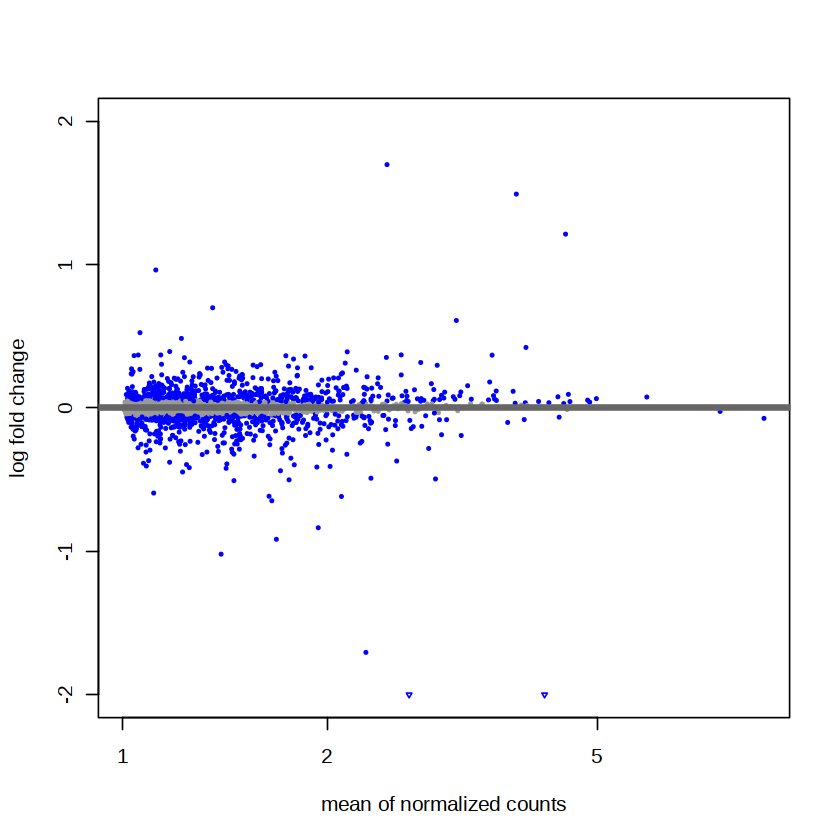

In [85]:
plotMA(res_4, ylim=c(-2,2))

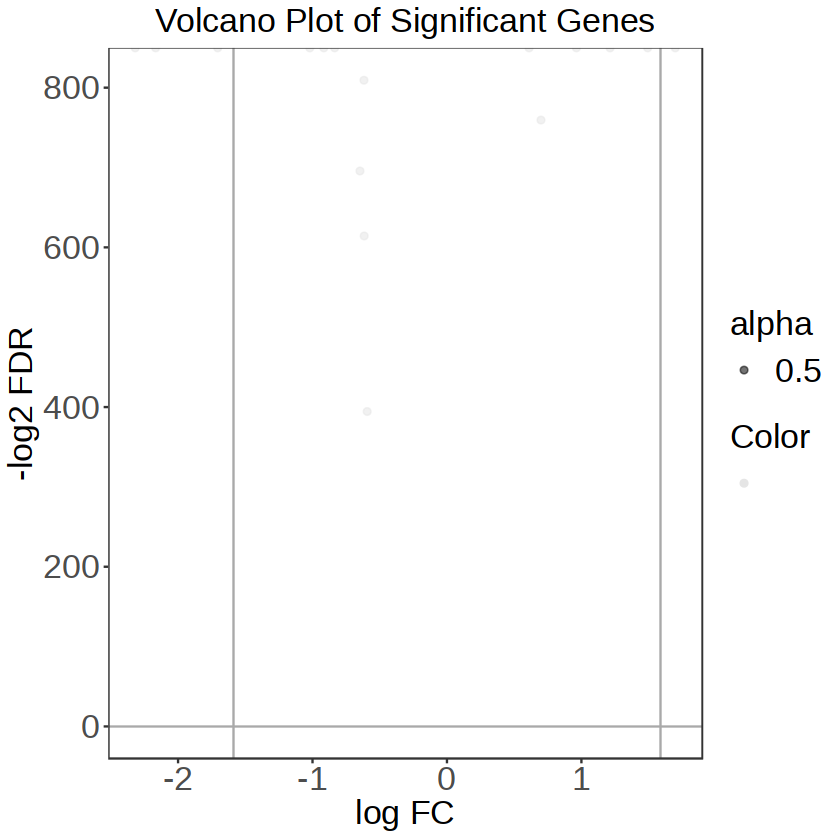

In [72]:
library(ggplot2)

# Subset the data frame to include only significant rows
significant_rows <- deg_df[deg_df$Significant, ]

# Plot volcano plot with only significant genes
ggplot(data=deg_df, aes(x=log2FoldChange, y=-log2(padj), color=Color, alpha=0.5)) + 
  geom_point(data=significant_rows) +
  scale_color_manual(values=c(' ' = "gray90")) +
  geom_vline(xintercept=c(-log2(3.0), log2(3.0)), col="darkgray") +
  geom_hline(yintercept=-log2(1), col="darkgray") +
  theme_minimal() +
  theme_bw() + 
  xlab('log FC') + 
  ylab('-log2 FDR') + 
  theme(text = element_text(size=20),
        plot.title = element_text(hjust = 0.5, size=20),
        axis.title = element_text(size = 20),
        legend.text=element_text(size=20),
        axis.text = element_text(size=20),
        panel.grid.minor = element_blank(),
        panel.grid.major = element_blank()) +
  ggtitle('Volcano Plot of Significant Genes')


In [56]:
deg_df$delabel = ''
deg_df[ISC_module29, 'delabel'] = ISC_module29
deg_df[interest_genes, 'delabel'] = interest_genes

In [89]:
dim(deg_df)

[1] 5000    6

In [87]:
deg_df['ZFP36L2', ]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NA,NA,NA,NA,NA,NA,NA


In [74]:
# Load the DESeqResults object
res_3 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/deseq_results_3.rds")

# Create a data frame from the DESeqResults
deg_df_3 <- as.data.frame(res_3)

In [76]:
# Add columns 'Significant' and 'Color'
deg_df_3$Significant <- deg_df_3$pvalue < 0.05 & abs(deg_df_3$log2FoldChange) > log2(1.5)

In [79]:
# Subset the data frame to view rows where 'Significant' is true
significant_rows <- deg_df_3[deg_df_3$Significant, ]

# Print or view the subsetted data frame
print(significant_rows)

          baseMean log2FoldChange       lfcSE      stat pvalue padj Significant
HTO-1     2.450326      1.2170361 0.007700532  158.0457      0    0        TRUE
HTO-3     2.641384     -1.2931068 0.010854010 -119.1363      0    0        TRUE
LINC00472 2.889008      0.7956133 0.007011220  113.4772      0    0        TRUE
TSB0251   4.182930      2.0969822 0.006280944  333.8642      0    0        TRUE
TSB0252   4.491411     -1.0620548 0.008384232 -126.6729      0    0        TRUE
TSB0253   3.800603     -1.2748419 0.009858703 -129.3113      0    0        TRUE


In [78]:
deg_df_3

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
A2ML1,1.005354,0.0008912186,0.012463609,0.07150567,9.429953e-01,NA,FALSE
AADACL2,1.005049,0.0008816830,0.012465477,0.07072999,9.436127e-01,NA,FALSE
AADACL2-AS1,1.045541,0.0246589963,0.012188581,2.02312284,4.306048e-02,9.909261e-02,FALSE
AADAT,1.081696,0.0039677230,0.012012881,0.33028904,7.411816e-01,8.963126e-01,FALSE
AARD,1.004285,0.0001249220,0.012471264,0.01001678,9.920079e-01,NA,FALSE
ABAT,1.242215,0.0528691614,0.011156815,4.73873238,2.150593e-06,1.100925e-05,FALSE
ABCA1,1.266470,0.0174945432,0.011084958,1.57822370,1.145142e-01,2.256783e-01,FALSE
ABCA13,1.016468,0.0004661929,0.012395734,0.03760914,9.699993e-01,9.893884e-01,FALSE
ABCA4,1.010872,-0.0102874295,0.012444493,-0.82666522,4.084268e-01,6.282186e-01,FALSE
